#Projeto NIDEC



###Importação de bibliotecas que serão utilizadas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.layers import Concatenate, Dense, Input, Embedding, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
##Garantindo que o modelo tenha sempre o mesmo desempenho
def reset_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Para garantir determinismo total no TensorFlow (pode deixar o treino mais lento)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

reset_seeds(42)

In [ ]:
def grafico_de_analise(x): #x = nome da feature desejada (como aparece no dataset)
  a = df[x].tolist() #conversão da coluna para uma lista
  b=[]
  for i in range(len(a)): # loop para obter o numero de amostras em forma de uma lista
    b.append(i)

  # plot de gráfico de dispersão da variável desejada
  plt.figure()
  plt.xlabel("Índice da amostra")
  plt.ylabel(x)
  plt.title(f"Dispersão da variável {x}")
  plt.scatter(b,a)
  plt.show()

###Importando o dataset

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel('CF0101L_115V_Life_expectation.xlsx') # nome do arquivo excel referente aos dados de teste utilizados para esse modelo
df                                                   #caso o arquivo estivesse em .csv o comando seria pd.read_excel e '.xlsx'

Saving CF0101L_115V_Life_expectation.xlsx to CF0101L_115V_Life_expectation.xlsx


,Voltage,Rotation,Power,Oven,Fence,Designator,Position,Component,Temperature
0,114.81,5344,109.2,29.5,35.2,Ambient A1,Right Side,Link E-Cap (C203),38.1
1,114.80,5344,114.1,29.6,35.3,Ambient A1,Right Side,Link E-Cap (C203),38.5
2,114.76,6320,147.1,38.7,50.5,Ambient A1,Right Side,Link E-Cap (C203),52.8
3,114.82,6152,149.8,52.9,65.0,Ambient A1,Right Side,Link E-Cap (C203),66.8
4,114.81,6322,129.0,78.3,94.8,Ambient A1,Right Side,Link E-Cap (C203),91.4
...,...,...,...,...,...,...,...,...,...
229,114.85,2704,80.1,52.9,65.0,Ambient,AVG,Link E-Cap (C205),71.0
230,114.83,4221,119.8,42.1,50.0,Ambient,AVG,Link E-Cap (C205),62.8
231,114.88,2220,50.0,42.2,50.0,Ambient,AVG,Link E-Cap (C205),54.5
232,114.79,3520,99.8,35.0,50.5,Ambient,AVG,Link E-Cap (C205),56.9


In [ ]:
pd.set_option('display.max_rows', None)

# Exibir todas as colunas
pd.set_option('display.max_columns', None)

### Análise de variáveis

####Análise de variáveis numéricas


Abaixo, criarei uma matriz de correlação entre as variáveis numéricas, para observar como elas se relacionam entre si

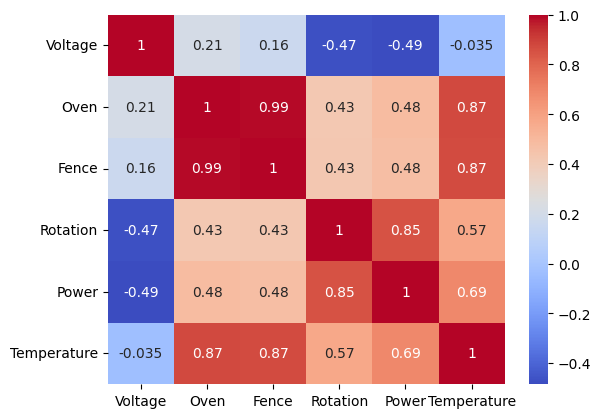

In [ ]:
sns.heatmap(df[['Voltage', 'Oven', 'Fence', 'Rotation', 'Power', 'Temperature']].corr(), annot=True, cmap='coolwarm')
plt.show()

- Focando na parte inferior da matriz na linha de temperature, podemos observar que a feature de voltage, não contribui muito para o resultado final, o que significa que pode ser relevante, testar o modelo sem essa feature.
- Focando na parte de Oven e Fence e na relação das duas entre si, podemos observar que elas são quase a mesma feature com uma relação quase igual 1 , talvez experimentar utilizar apenas uma das duas também pode ser vantajoso, ou uní-las em uma variável só.

**Obs**: esses experimentos foram feitos e, um deles, se provou extremamente vantajoso, podendo ser observado ao fim deste código, enquanto o outro acabou piorando o modelo e foi desconsiderado para evitar poluição visual

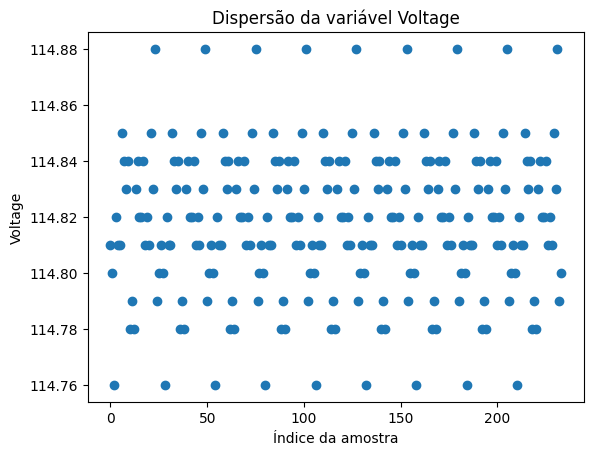

In [ ]:
#Plot dos valores de tensão para todas as amostras
grafico_de_analise('Voltage')

- Tensão opera ao redor de uma faixa fixa de 114.82V aproximadamente
- Por atuar em uma única faixa, faz sentido utilizar StandardScaler na normalização

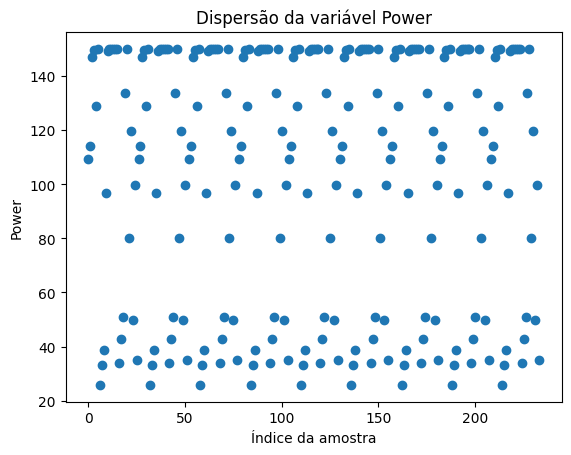

In [ ]:
#Plot dos valores de potÇencia para todas as amostras
grafico_de_analise('Power')

- A feature Power tem uma amostragem quase contínua ao da mediana
- A melhor opção é utilizar StandardScaler


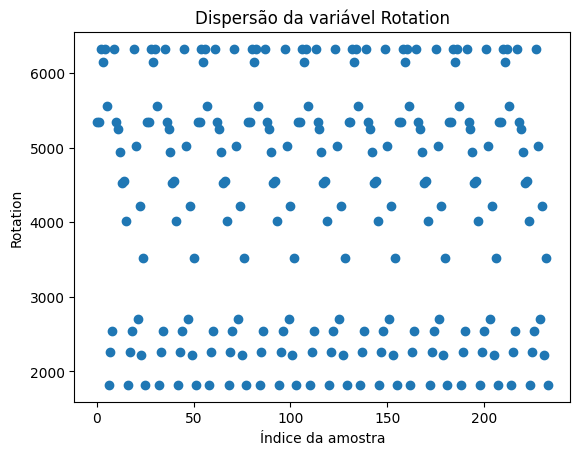

In [ ]:
#Plot dos valores de rotação para todas as amostras
grafico_de_analise('Rotation')

- Rotação atua em faixas distintas mas de maneira contínua
- Para essa feature, tanto o MinMax quanto o StandardScaler funcionam, dado que não há outliers

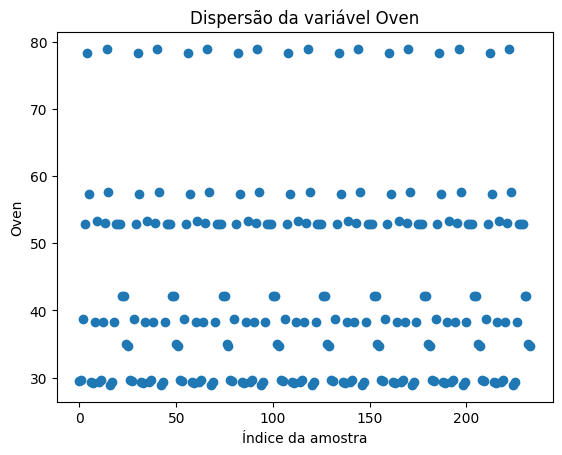

In [ ]:
#Plot dos valores de temperatura de Oven para todas as amostras
grafico_de_analise('Oven')

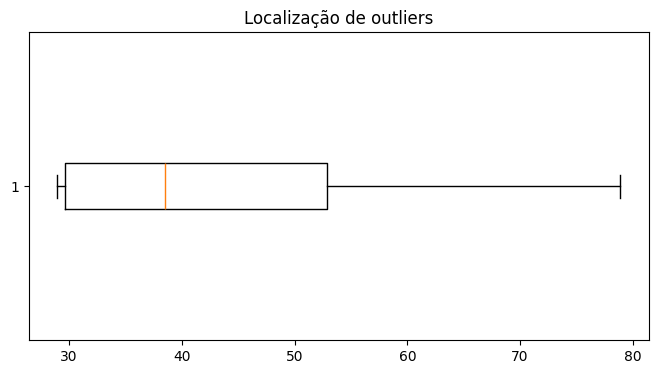

Quantidade de outliers: 0


In [ ]:
#Plot do boxplot para verificar outliers
plt.figure(figsize=(8, 4))
plt.boxplot(df['Oven'], vert=False)
plt.title("Localização de outliers")
plt.show()

#Abaixo o cáculo feito pelo boxplot para calcular outliers, mas para mostrar a quantidade de forma numérica
Q1 = df['Oven'].quantile(0.25)
Q3 = df['Oven'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contar pontos fora dos limites
outliers = df[(df['Oven'] < limite_inferior) | (df['Oven'] > limite_superior)]
print(f"Quantidade de outliers: {len(outliers)}")


- Conforme confirmado pelo boxplot não há outliers novamente
- A variável também atua em faixas distintas, portanto será utilizado MinMaxScaler

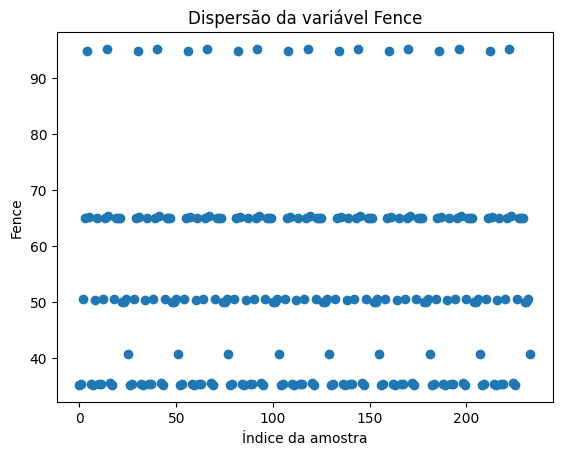

In [ ]:
#Plot dos valores de temperatura de Fence para todas as amostras
grafico_de_analise('Fence')

- Novamente uma variável que atua em zonas
- Também será utilizado MinMaxScaler

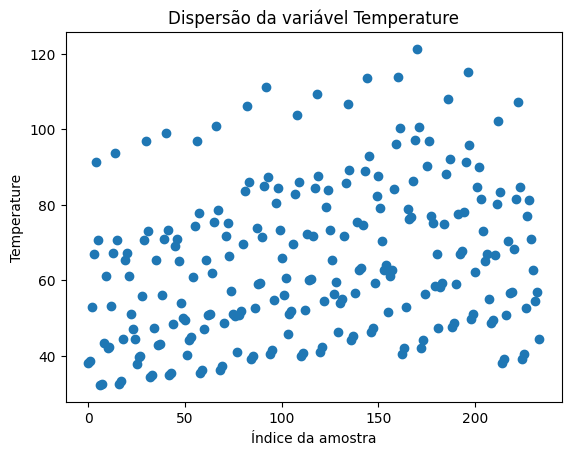

In [ ]:
#Plot dos valores de temperatura final dos componentes para todas as amostras
grafico_de_analise('Temperature')

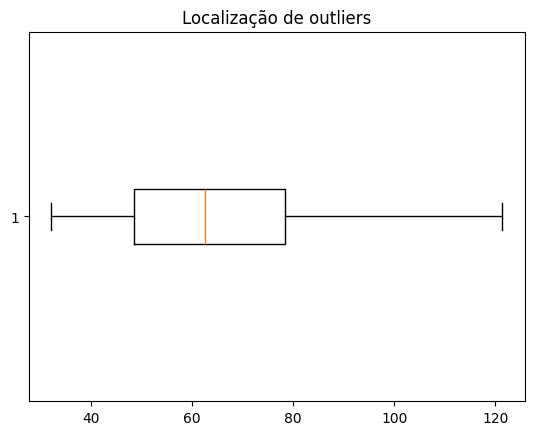

Quantidade de outliers: 0


In [ ]:
#Boxplot e cáculo de outliers para variável Temperature
plt.figsize=(8, 4)
plt.boxplot(df['Temperature'], vert=False)
plt.title("Localização de outliers")
plt.show()

Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Temperature'] < limite_inferior) | (df['Temperature'] > limite_superior)]
print(f"Quantidade de outliers: {len(outliers)}")

- Tanto pelo gráfico de dispersão quanto pelo boxplot podemos observar que não há outliers
- Como não há "faixas" de atuação específicas, usaremos StandardScaler para normalização

####Análise de variáveis categóricas


Plotar em diferentes gráficos essas variáveis, causaria muita poluição visual e dificultaria o entendimento, faz mais sentido apenas "printar" quais são as variáveis que se repetem e quantas vezes

In [ ]:
componentes = df['Designator'].unique()
print(componentes)

x = []
for i in range(len(componentes)):
  x.append(int(df['Designator'][df['Designator'] == componentes[i]].count()))

print(x)

['Ambient A1' 'Ambient A2' 'Ambient A3' 'Ambient A4' 'Ambient A5'
 'Ambient A6' 'C205' 'C009' 'Ambient']
[26, 26, 26, 26, 26, 26, 26, 26, 26]


In [ ]:
componentes = df['Position'].unique()
print(componentes)

x = []
for i in range(len(componentes)):
  x.append(int(df['Position'][df['Position'] == componentes[i]].count()))

print(x)

['Right Side' 'Left Side' 'Fuse Side' 'DSP Side'
 'In between C205 and C009' 'Ambient C009' 'Inside' 'Case' 'AVG']
[26, 26, 26, 26, 26, 26, 26, 26, 26]


####

In [ ]:
componentes = df['Component'].unique()
print(componentes)

x = []
for i in range(len(componentes)):
  x.append(int(df['Component'][df['Component'] == componentes[i]].count()))

print(x)

['Link E-Cap (C203)' 'Link E-Cap (C205)' 'SMPS E-Cap (C009)']
[52, 130, 52]


Como o teste foi realizado em um único produto, os componentes serão sempre os mesmos, a combinação de "Component", "Designator" e "Position" nunca se alterará além dos dados já tabelados. Portanto, faz sentido unir essas três colunas em uma só, antes de aplicar a transformação de numérica em categórica

###Conversão de variáveis numéricas em categóricas

Redes neurais não são capazes de compreender variáveis categóricas, então verificarei quantas possibilidades de componentes existem, caso seja um número pequeno, utilizarei one_hot_encoding, se forem muitas possibilidades usaremos embedding quando criarmos a rede neural

In [ ]:
df['Component geral'] = (df['Component'] + df['Designator'] + df['Position']).astype('category') #criação da nova coluna que concatena as antiags
df.drop(columns = ['Component', 'Designator', 'Position'], inplace = True)                       #remoção das colunas antigas
df

,Voltage,Rotation,Power,Oven,Fence,Temperature,Component geral
0,114.81,5344,109.2,29.5,35.2,38.10,Link E-Cap (C203)Ambient A1Right Side
1,114.80,5344,114.1,29.6,35.3,38.50,Link E-Cap (C203)Ambient A1Right Side
2,114.76,6320,147.1,38.7,50.5,52.80,Link E-Cap (C203)Ambient A1Right Side
3,114.82,6152,149.8,52.9,65.0,66.80,Link E-Cap (C203)Ambient A1Right Side
4,114.81,6322,129.0,78.3,94.8,91.40,Link E-Cap (C203)Ambient A1Right Side
5,114.81,5554,150.0,57.3,65.1,70.50,Link E-Cap (C203)Ambient A1Right Side
6,114.85,1821,25.8,29.3,35.3,32.20,Link E-Cap (C203)Ambient A1Right Side
7,114.84,2261,33.0,29.2,35.2,32.50,Link E-Cap (C203)Ambient A1Right Side
8,114.83,2536,38.9,38.3,50.4,43.40,Link E-Cap (C203)Ambient A1Right Side
9,114.84,6315,96.9,53.3,65.0,61.00,Link E-Cap (C203)Ambient A1Right Side


In [ ]:
len(df['Component geral'].unique())  #Mostrar o número de categorias da nova variável

9

Como podemos observar, há **9** categorias diferentes para a feature "Component geral". utilizaremos embedding para que essa feature possa entrar na rede neural

###Divisão em treino e teste e escala de variáveis numéricas

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['Temperature'], axis = 1), df['Temperature'],
                                                    test_size = 0.15, random_state = 42)

####Escala de variáveis numéricas

**Relembrando**: de acordo com as análises feitas anteriormente, chegamos a conclusão que, a malhor forma de escalar as variáveis é aplicando StandardScaler nas features Voltage, Power, Rotation e Temperature, e aplicar MinMaxScaler às demais.

In [ ]:
voltage_scaler = StandardScaler()
x_train['Voltage'] = voltage_scaler.fit_transform(x_train[['Voltage']])
x_test['Voltage'] = voltage_scaler.transform(x_test[['Voltage']])

power_scaler = StandardScaler()
x_train['Power'] = power_scaler.fit_transform(x_train[['Power']])
x_test['Power'] = power_scaler.transform(x_test[['Power']])

rotation_scaler = StandardScaler()
x_train['Rotation'] = rotation_scaler.fit_transform(x_train[['Rotation']])
x_test['Rotation'] = rotation_scaler.transform(x_test[['Rotation']])

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))

# o fit_transform aprende com os dados de teste uma regra para a escala e a aplica aos dados
# o transform apenas pega essa regra já estabelecida pelo treino e aplica no teste

In [ ]:
oven_scaler = MinMaxScaler(feature_range = (0, 1)) #Esse feature range define o intervalo de máximo e mínimo do scaler
x_train['Oven'] = oven_scaler.fit_transform(x_train[['Oven']])
x_test['Oven'] = oven_scaler.transform(x_test[['Oven']])

fence_scaler = MinMaxScaler(feature_range = (0, 1))
x_train['Fence'] = fence_scaler.fit_transform(x_train[['Fence']])
x_test['Fence'] = fence_scaler.transform(x_test[['Fence']])



###Criação e Treinamento do modelo

In [ ]:
componente_idx = df['Component geral'].astype('category').cat.codes
x_train_cat_codes = componente_idx[x_train.index]
x_test_cat_codes = componente_idx[x_test.index]

x_train_numerical = x_train.drop(columns=['Component geral'])
x_test_numerical = x_test.drop(columns=['Component geral'])

In [ ]:
input_numerical = Input(shape=(5,)) #criando camada de input
input_categorical = Input(shape=(1,))

#criando camada de embedding para variáveis categóricas
embedding = Embedding(input_dim = 9, output_dim = 3)(input_categorical)
flatten_layer = Flatten()(embedding)

concatenated_inputs = Concatenate()([input_numerical, flatten_layer])

#criando rede neural com apenas uma camada de 45 neurônios (por serem poucos dados uma camada se saiu melhor)
dense1 = Dense(45, activation = 'relu')(concatenated_inputs)

#criando camada de saída
output_layer = Dense(1, activation = None)(dense1)

#criando e compilando o modelo
modelo1 = Model(inputs = [input_numerical,input_categorical ], outputs = output_layer)

modelo1.compile(optimizer = 'adam', loss = 'mae')

In [ ]:
#para esse modelo, como o número de dados é menor, vou inserir duas condições: se a validação não melhorar em até 5 épocas de treino, o modelo
#reduz o lerning rate, e se até 10 épocas não haver melhora o modelo para

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.01, patience = 5,
                                                    min_lr = 1e-100, restore_best_weights = True)
early_stop = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 15)

history = modelo1.fit(
    x = [x_train_numerical, x_train_cat_codes],
    y = y_train,
    epochs = 150,
    batch_size = 30, # quantas amostras o modelo recebe por época de treino
    validation_data = ([x_test_numerical, x_test_cat_codes], y_test),
    validation_split = 0.2,
    callbacks = [lr_scheduler, early_stop],
    verbose = 1
)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.8314 - val_loss: 0.9492 - learning_rate: 0.0010
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.7704 - val_loss: 0.8705 - learning_rate: 0.0010
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7155 - val_loss: 0.7965 - learning_rate: 0.0010
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6642 - val_loss: 0.7329 - learning_rate: 0.0010
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6187 - val_loss: 0.6763 - learning_rate: 0.0010
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5810 - val_loss: 0.6314 - learning_rate: 0.0010
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5532 - val_loss: 0.5980 - learning_rate: 0.0010
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5331 - val_loss: 0.5726 - learning_rate: 0.0010
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5144 - val_loss: 0.5517 - learning_rate: 0.0010
Epoch 10/150
7/7 ━━━━━━━━━━━

In [ ]:
test_mae = modelo1.evaluate([x_test_numerical, x_test_cat_codes], y_test, verbose=0)
print(f"Mean Absolute Error no teste: {test_mae:.4f}") # Pontuação final da MAE em relação ao teste

Mean Absolute Error no teste: 0.0457


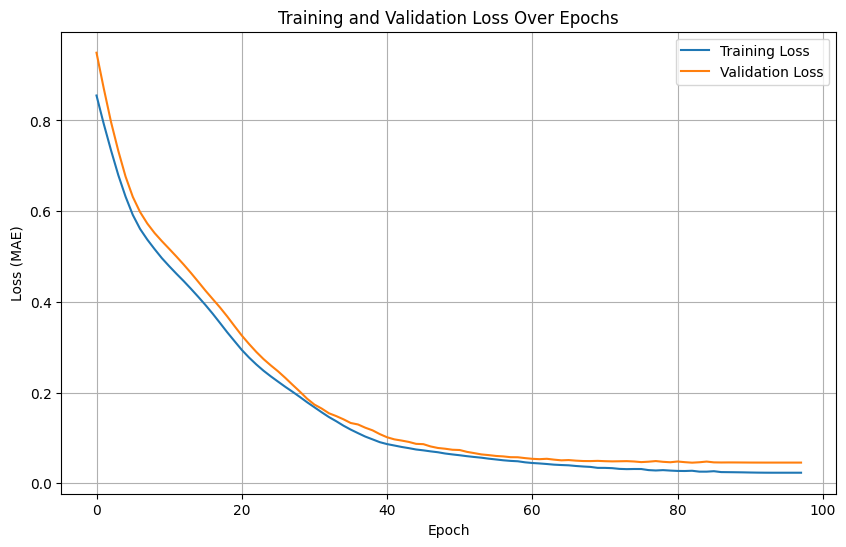

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(True)
plt.show()

Podemos ver que as curvas se seguiram de forma bastante similar, o que nos prova que o modelo teve um resultado coerente e não houve overfitting

In [ ]:
# Fazer previsões com o modelo1 no conjunto de teste
y_pred_scaled_model1 = modelo1.predict([
    x_test_numerical,
    x_test_cat_codes
])

# Inverter a escala das previsões para a escala original
y_pred_model1_original = y_scaler.inverse_transform(y_pred_scaled_model1.reshape(-1, 1))

# Inverter a escala dos valores y_test para a escala original para comparação
y_test_original_model1 = y_scaler.inverse_transform(y_test.reshape(-1, 1))

# Calcular o MAPE - erro medio absoluto percentual (saberemos o erro percentual do modelo)
mape_model1 = mean_absolute_percentage_error(y_test_original_model1, y_pred_model1_original)

print(f"O MAPE para o Modelo1 é: {mape_model1:.2%}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
O MAPE para o Modelo1 é: 1.40%


**Observação**: o modelo obteve um desempenho satisfatório nos dados de teste com taxa de erro próxima de 1.4%. Entretanto, sua verdadeira precisão, devido a alta MAE no treino e na validação, chega próxima de 97% (o que ainda é um modelo super preciso dado o pequeno conjunto de dados)

##Teste para modelo sem a feature Voltage

In [ ]:
x_train_no_voltage = x_train.drop(columns = ['Voltage'])
x_test_no_voltage = x_test.drop(columns = ['Voltage'])

In [ ]:

componente_idx = df['Component geral'].astype('category').cat.codes
x_train_cat_codes = componente_idx[x_train_no_voltage.index]
x_test_cat_codes = componente_idx[x_test_no_voltage.index]

x_train_no_voltage = x_train_no_voltage.drop(columns=['Component geral'])
x_test_no_voltage = x_test_no_voltage.drop(columns=['Component geral'])

input_categorical2 = Input(shape=(1,))
input_numerical_no_voltage = Input(shape=(4,))

embedding2 = Embedding(input_dim = 9, output_dim = 3)(input_categorical2)
flatten_layer2 = Flatten()(embedding2)

concatenated_inputs2 = Concatenate()([flatten_layer2,input_numerical_no_voltage])

dense2 = Dense(48, activation = 'relu')(concatenated_inputs2)

output_layer2 = Dense(1, activation = None)(dense2)

modelo2 = Model(inputs = [input_numerical_no_voltage, input_categorical2], outputs = output_layer2)

modelo2.compile(optimizer = 'adam', loss = 'mae')

In [ ]:
history2 = modelo2.fit(
    x = [x_train_no_voltage, x_train_cat_codes],
    y = y_train,
    epochs = 150,
    batch_size = 30,
    validation_split = 0.2,
    validation_data = ([x_test_no_voltage, x_test_cat_codes], y_test),
    callbacks = [lr_scheduler, early_stop],
    verbose = 1
)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.9965 - val_loss: 1.1113 - learning_rate: 0.0010
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9218 - val_loss: 1.0370 - learning_rate: 0.0010
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8555 - val_loss: 0.9668 - learning_rate: 0.0010
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7948 - val_loss: 0.8997 - learning_rate: 0.0010
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7382 - val_loss: 0.8330 - learning_rate: 0.0010
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6851 - val_loss: 0.7685 - learning_rate: 0.0010
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6379 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5983 - val_loss: 0.6551 - learning_rate: 0.0010
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5663 - val_loss: 0.6147 - learning_rate: 0.0010
Epoch 10/150
7/7 ━━━━━━━━━━━

In [ ]:
test_mae = modelo2.evaluate([x_test_no_voltage, x_test_cat_codes], y_test, verbose=0)
print(f"Mean Absolute Error no teste: {test_mae:.4f}")

Mean Absolute Error no teste: 0.0353


In [ ]:
# Fazer previsões com o modelo2 no conjunto de teste
y_pred_scaled_model2 = modelo2.predict([
    x_test_no_voltage,
    x_test_cat_codes
])

# Inverter a escala das previsões para a escala original
y_pred_model2_original = y_scaler.inverse_transform(y_pred_scaled_model2.reshape(-1, 1))

# Inverter a escala dos valores y_test para a escala original para comparação
y_test_original_model2 = y_scaler.inverse_transform(y_test.reshape(-1, 1))

# Calcular o MAPE - erro medio absoluto percentual (saberemos o erro percentual do modelo)
mape_model2 = mean_absolute_percentage_error(y_test_original_model2, y_pred_model2_original)

print(f"O MAPE para o Modelo2 é: {mape_model2:.2%}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
O MAPE para o Modelo2 é: 1.12%


In [ ]:
melhor_modelo = modelo2.save('modelo2.keras') ##salvando um modelo que até agora obterve melhor resultado com MAE final de 0.0344

Plot de gráfico para análise de desempenho

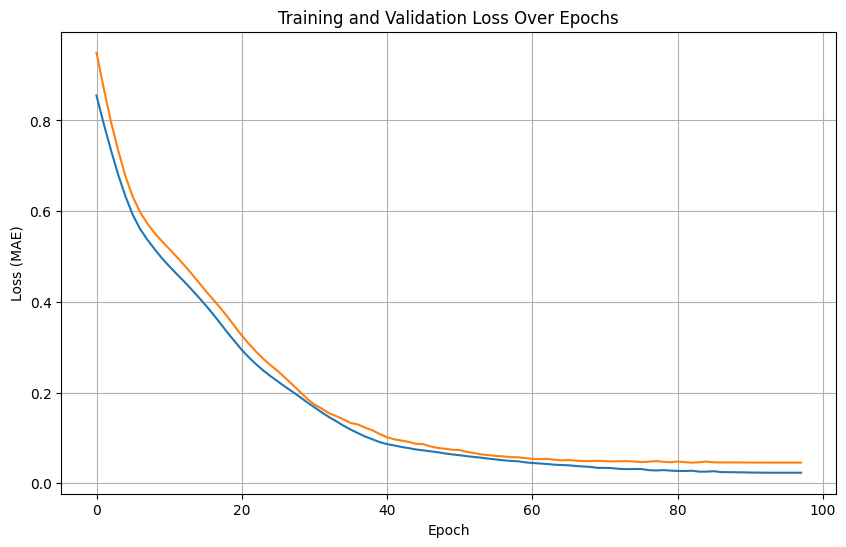

In [ ]:
plt.figure(figsize =(10,6))
plt.plot(history.history['loss'], label ='Training Loss' )# history.history é o histórico do modelo, 'loss' é o conjunto dos erros de treino
plt.plot(history.history['val_loss'], label = 'Val_Loss')# history.history é o histórico do modelo, 'val_loss' é o conjunto dos erros de validação
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.grid(True)
plt.show()

- De forma similar a outra análise feita, retirar a feature de **Tensão de entrada**, resultou em um desempenho mais preciso do modelo.
- O gráfico indica que não houve overfit, dado que ambas as perdas descresceram juntas e estão bem próximas uma da outra.

Vamos observar seu erro percentual e criar um código para ele prever as temperaturas

##Código para previsão das temperaturas

In [ ]:
#Código para identificação numérica dos componentes
#Assim encontra-se o componente desejado e para previsão, usa-se esse número no código abaixo
componente_idx = df['Component geral'].astype('category').cat.codes
a = {}

for i in range(len(componente_idx)):
  a[df['Component geral'][i]] = int(componente_idx[i])

print(a)

{'Link E-Cap (C203)Ambient A1Right Side': 0, 'Link E-Cap (C203)Ambient A2Left Side': 1, 'Link E-Cap (C205)Ambient A3Fuse Side': 2, 'Link E-Cap (C205)Ambient A4DSP Side': 3, 'Link E-Cap (C205)Ambient A5In between C205 and C009': 4, 'SMPS E-Cap (C009)Ambient A6Ambient C009': 7, 'Link E-Cap (C205)C205Inside': 6, 'SMPS E-Cap (C009)C009Case': 8, 'Link E-Cap (C205)AmbientAVG': 5}


In [ ]:
##Código para previsão de pontos futuros

#aqui inserimos os dados desejados
input_rotation = 2704
input_power = 80.1
input_oven = 52
input_fence = 65
input_component_code = 5

print(f"Original input values: Rotation={input_rotation}, Power={input_power}, Oven={input_oven}, Fence={input_fence}, Component Code={input_component_code}")

##aqui escalamos os dados inseridos para se adequarem à escala realizada
scaled_rotation = rotation_scaler.transform(pd.DataFrame([[input_rotation]], columns=['Rotation']))[0][0]
scaled_power = power_scaler.transform(pd.DataFrame([[input_power]], columns=['Power']))[0][0]
scaled_oven = oven_scaler.transform(pd.DataFrame([[input_oven]], columns=['Oven']))[0][0]
scaled_fence = fence_scaler.transform(pd.DataFrame([[input_fence]], columns=['Fence']))[0][0]


specific_numerical_input = np.array([[scaled_rotation, scaled_power, scaled_oven, scaled_fence]])

specific_categorical_input = np.array([[input_component_code]])

print(f"\nScaled Numerical Input: {specific_numerical_input}")
print(f"Categorical Input Code: {specific_categorical_input}")

#aqui o modelo treinado faz a previsão de acordo com os dados de entrada escalados
predicted_scaled_temperature = modelo2.predict([
    specific_numerical_input,
    specific_categorical_input
])

#temperatura transformada de volta à escala normal
predicted_original_temperature = y_scaler.inverse_transform(predicted_scaled_temperature.reshape(-1, 1))

#print da temperatura prevista escalada e na escala real
print(f"\nPredicted Temperature (scaled): {predicted_scaled_temperature[0][0]:.4f}")
print(f"Predicted Temperature (original scale): {predicted_original_temperature[0][0]:.2f} °C")

Original input values: Rotation=2704, Power=80.1, Oven=52, Fence=65, Component Code=5

Scaled Numerical Input: [[-0.94340819 -0.50837827  0.462       0.49749583]]
Categorical Input Code: [[5]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Predicted Temperature (scaled): 0.3198
Predicted Temperature (original scale): 70.85 °C


**Conclusão**: Sem a feature 'Voltage' o modelo apresentou um desempenho ainda melhor, beirando uma taxa de acerto de 99% em média

Para valores de previsão com resultados mais baixos, observei que a taxa de acerto pode variar para 98% no mínimo, valores de previsão que geram temperaturas mais altas (de 50 para cima) o acerto se aproxima de 100%

###Heatmap de erro máximo por componente por faixas de Rotação

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


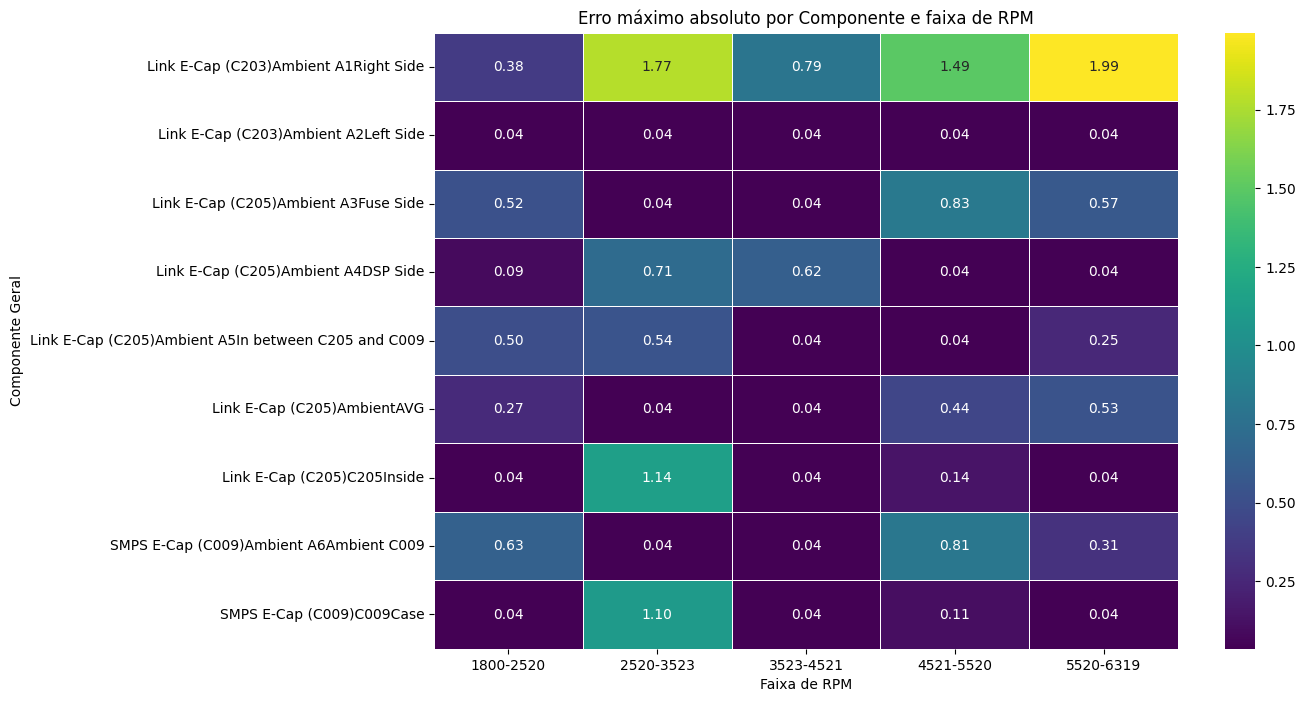

In [ ]:
# Esse código vai criar uma espécie de "tabela" com os erros máximos separados por faixa de rotação para cada componente
# Dessa forma haverá mais certeza se para a faixa escolhida de predição, o modelo conseguirá fazer uma boa aproximação

bins = [1800, 2520, 3523, 4521, 5520, 6319]
labels = ['1800-2520','2520-3523', '3523-4521','4521-5520','5520-6319']

df["RPM_range"] = pd.cut(df["Rotation"], bins=bins, labels=labels, include_lowest=True)


y_true_temp = pd.Series(y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten(), index=x_test.index)
df["y_true"] = y_true_temp.reindex(df.index, fill_value=0)


y_pred_temp = pd.Series(y_scaler.inverse_transform(modelo2.predict([x_test_no_voltage, x_test_cat_codes])).flatten(), index=x_test.index)
df["y_pred"] = y_pred_temp.reindex(df.index, fill_value=0.0353)

# Erro  absoluto
df["error"] = np.abs(df["y_pred"] - df["y_true"])

# Agrupar por componente + faixa, calculando o ERRO MÁXIMO
error_table = (
    df.groupby(["Component geral", "RPM_range"], observed=False)["error"]
    .max()
    .reset_index()
)

pivot = error_table.pivot(
    index="Component geral",
    columns="RPM_range",
    values="error"
)


plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Erro máximo absoluto por Componente e faixa de RPM')
plt.xlabel('Faixa de RPM')
plt.ylabel('Componente Geral')
plt.show()

Esse mapa de calor é feito em relação às faixas da feature com menor correlção com a variável alvo. Garantindo dessa forma maior precisão, visto que essa feature é a que mais contribui para a instabilidade do modelo